In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split,
    KFold,
    GridSearchCV
)

from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import Ridge
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import joblib

In [2]:
DATA_PATH = "../data/processed/voiceiq_features_1000.csv"

df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (1000, 53)


In [3]:
metadata_columns = [
    "sample_id",
    "system_id"
]

target_column = "mos"

feature_columns = [
    column
    for column in df.columns
    if column not in metadata_columns + [target_column]
]

X = df[feature_columns]
y = df[target_column]

print("Number of features:", X.shape[1])
print("Number of samples:", X.shape[0])

Number of features: 50
Number of samples: 1000


In [4]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])

Training samples: 800
Testing samples: 200


In [6]:
ridge_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'scaler',
        StandardScaler()
    ),
    (
        'model',
        Ridge()
    )
])

In [7]:
ridge_param_grid = {
    "model__alpha": [
        0.01,
        0.1,
        1.0,
        10.0,
        100.0
    ]
}

In [9]:
cv = KFold(
    n_splits = 5,
    shuffle = True,
    random_state = 42
)

In [10]:
ridge_search = GridSearchCV(
    estimator = ridge_pipeline,
    param_grid = ridge_param_grid,
    scoring = 'neg_root_mean_squared_error',
    cv = cv,
    n_jobs =-1,
    return_train_score = True
)

ridge_search.fit(
    X_train,
    y_train
)

print("Best Ridge parameters:")
print(ridge_search.best_params_)

print("\nBest CV RMSE:")
print(-ridge_search.best_score_)

Best Ridge parameters:
{'model__alpha': 100.0}

Best CV RMSE:
0.5486492983928356


In [11]:
rf_pipeline = Pipeline([
    (
        'imputer',
        SimpleImputer(strategy='median')
    ),
    (
        'model',
        RandomForestRegressor(
            random_state = 42,
            n_jobs = -1
        )
    )
])

In [12]:
rf_param_grid = {
    'model__n_estimators':[
        100,200,300
    ],
    'model__max_depth':[
        None,10,20
    ],
    'model__min_samples_split':[
        2,5,10
    ]
}

In [13]:
rf_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=rf_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

rf_search.fit(
    X_train,
    y_train
)

print("Best Random Forest parameters:")
print(rf_search.best_params_)

print("\nBest CV RMSE:")
print(-rf_search.best_score_)

Best Random Forest parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}

Best CV RMSE:
0.546609664845676


In [14]:
gb_pipeline = Pipeline([
    (
        "imputer",
        SimpleImputer(strategy="median")
    ),
    (
        "model",
        GradientBoostingRegressor(
            random_state=42
        )
    )
])

In [15]:
gb_param_grid = {
    "model__n_estimators": [
        50,
        100,
        200
    ],
    
    "model__learning_rate": [
        0.01,
        0.05,
        0.1
    ],
    
    "model__max_depth": [
        2,
        3,
        5
    ]
}

In [16]:
gb_search = GridSearchCV(
    estimator=gb_pipeline,
    param_grid=gb_param_grid,
    scoring="neg_root_mean_squared_error",
    cv=cv,
    n_jobs=-1,
    return_train_score=True
)

gb_search.fit(
    X_train,
    y_train
)

print("Best Gradient Boosting parameters:")
print(gb_search.best_params_)

print("\nBest CV RMSE:")
print(-gb_search.best_score_)

Best Gradient Boosting parameters:
{'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50}

Best CV RMSE:
0.5533716411264372


In [21]:
tuned_models = {
    'Ridge': ridge_search,
    'Random Forest': rf_search,
    'Gradient Boosting': gb_search
}

tuning_results = []
for name,model in tuned_models.items():
    tuning_results.append({
        'Model':name,
        'Best CV RMSE': -model.best_score_,
        'Best Parameters': model.best_params_
    })

tuning_results_df = pd.DataFrame(
    tuning_results
)

tuning_results_df = tuning_results_df.sort_values(
    by="Best CV RMSE"
)

tuning_results_df

,Model,Best CV RMSE,Best Parameters
1,Random Forest,0.546610,"{'model__max_depth': 20, 'model__min_samples_s..."
0,Ridge,0.548649,{'model__alpha': 100.0}
2,Gradient Boosting,0.553372,"{'model__learning_rate': 0.1, 'model__max_dept..."


In [22]:
best_tuned_name = tuning_results_df.iloc[0]["Model"]

best_search = tuned_models[best_tuned_name]

best_tuned_model = best_search.best_estimator_

print("Best tuned model:", best_tuned_name)
print("Best parameters:")
print(best_search.best_params_)

Best tuned model: Random Forest
Best parameters:
{'model__max_depth': 20, 'model__min_samples_split': 2, 'model__n_estimators': 100}


In [23]:
test_predictions = best_tuned_model.predict(
    X_test
)

test_mae = mean_absolute_error(
    y_test,
    test_predictions
)

test_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        test_predictions
    )
)

test_r2 = r2_score(
    y_test,
    test_predictions
)
print("Final Test Results")
print()
print("Model:", best_tuned_name)
print("MAE:", test_mae)
print("RMSE:", test_rmse)
print("R²:", test_r2)

Final Test Results

Model: Random Forest
MAE: 0.4132379909918512
RMSE: 0.5112928719194956
R²: 0.4840217095121174


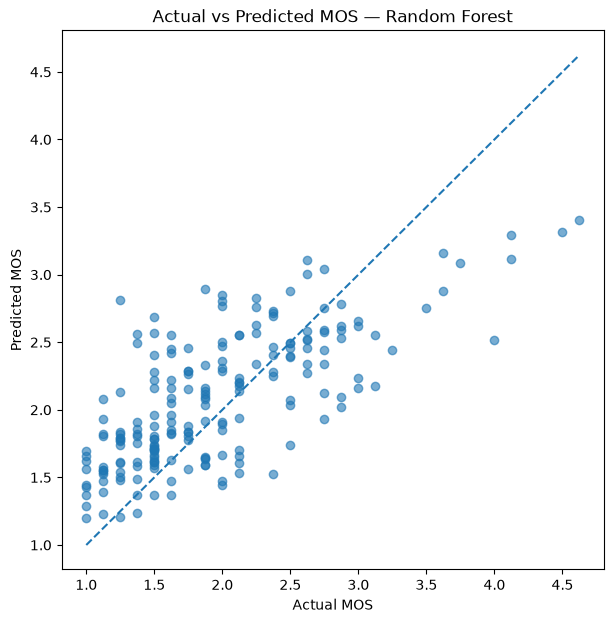

In [24]:
plt.figure(figsize=(7, 7))

plt.scatter(
    y_test,
    test_predictions,
    alpha=0.6
)

min_value = min(
    y_test.min(),
    test_predictions.min()
)

max_value = max(
    y_test.max(),
    test_predictions.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.xlabel("Actual MOS")
plt.ylabel("Predicted MOS")
plt.title(
    f"Actual vs Predicted MOS — {best_tuned_name}"
)

plt.show()

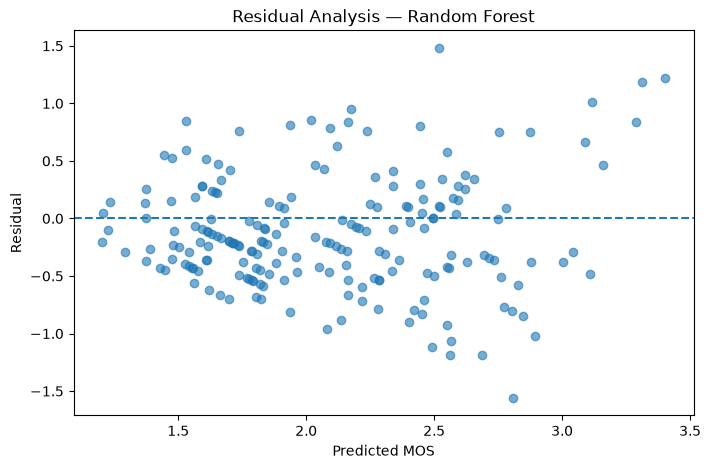

In [27]:
residuals = y_test - test_predictions

plt.figure(figsize=(8,5))

plt.scatter(
    test_predictions,
    residuals,
    alpha = 0.6
)
plt.axhline(
    0,linestyle = '--'
)
plt.xlabel("Predicted MOS")
plt.ylabel("Residual")
plt.title(
    f"Residual Analysis — {best_tuned_name}"
)

plt.show()

In [28]:
if best_tuned_name in [
    "Random Forest",
    "Gradient Boosting"
]:

    model = best_tuned_model.named_steps["model"]

    importances = model.feature_importances_

    feature_importance_df = pd.DataFrame({
        "Feature": feature_columns,
        "Importance": importances
    })

    feature_importance_df = feature_importance_df.sort_values(
        by="Importance",
        ascending=False
    )

    feature_importance_df.head(20)

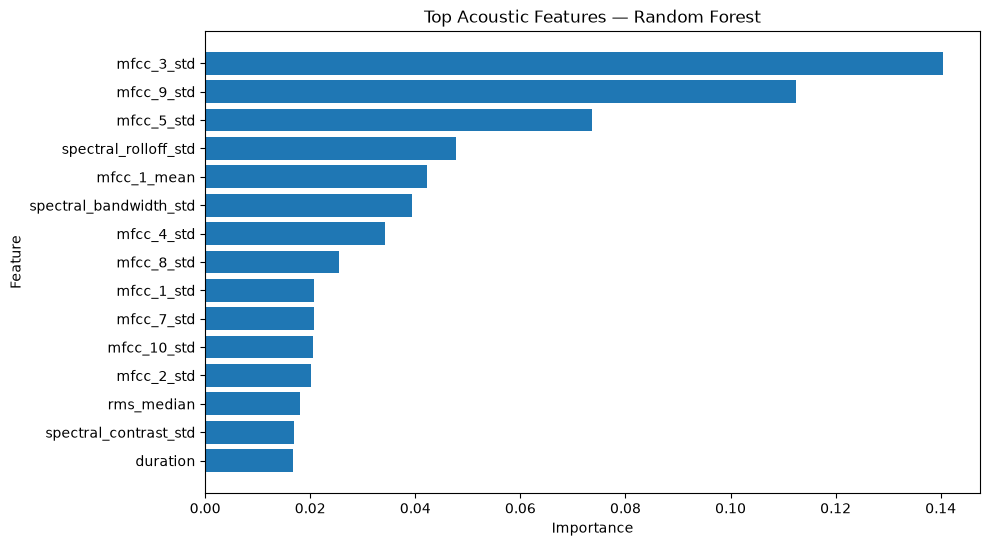

In [29]:
top_features = feature_importance_df.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features["Feature"][::-1],
    top_features["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title(
    f"Top Acoustic Features — {best_tuned_name}"
)

plt.show()

In [30]:
FEATURE_IMPORTANCE_PATH = (
    "../reports/metrics/"
    "classical_feature_importance.csv"
)

os.makedirs(
    "../reports/metrics",
    exist_ok=True
)

if best_tuned_name in [
    "Random Forest",
    "Gradient Boosting"
]:

    feature_importance_df.to_csv(
        FEATURE_IMPORTANCE_PATH,
        index=False
    )

    print(
        "Feature importance saved successfully!"
    )

Feature importance saved successfully!


In [31]:
MODEL_DIR = "../models/classical"

os.makedirs(
    MODEL_DIR,
    exist_ok=True
)

MODEL_PATH = (
    f"{MODEL_DIR}/"
    f"voiceiq_{best_tuned_name.lower().replace(' ', '_')}_tuned.joblib"
)

joblib.dump(
    best_tuned_model,
    MODEL_PATH
)

print("Tuned model saved successfully!")
print("Path:", MODEL_PATH)

Tuned model saved successfully!
Path: ../models/classical/voiceiq_random_forest_tuned.joblib


In [32]:
loaded_model = joblib.load(
    MODEL_PATH
)

loaded_predictions = loaded_model.predict(
    X_test
)

loaded_rmse = np.sqrt(
    mean_squared_error(
        y_test,
        loaded_predictions
    )
)

print("Model loaded successfully!")
print("Loaded model RMSE:", loaded_rmse)

Model loaded successfully!
Loaded model RMSE: 0.5112928719194956


In [33]:
final_metrics = pd.DataFrame({
    "Model": [best_tuned_name],
    "MAE": [test_mae],
    "RMSE": [test_rmse],
    "R2": [test_r2]
})

METRICS_PATH = (
    "../reports/metrics/"
    "best_classical_model_metrics.csv"
)

final_metrics.to_csv(
    METRICS_PATH,
    index=False
)

print("Final metrics saved successfully!")

Final metrics saved successfully!



We improved the VoiceIQ classical ML pipeline using
hyperparameter tuning.

We learned:

- Parameters vs hyperparameters
- GridSearchCV
- Cross-validation
- Hyperparameter search
- Pipeline-based tuning
- RMSE-based model selection
- Untouched test-set evaluation
- Feature importance
- Model serialization

Models tuned:

1. Ridge Regression
2. Random Forest
3. Gradient Boosting

The best tuned model is saved in:

models/classical/

The final evaluation metrics are saved in:

reports/metrics/